<a href="https://colab.research.google.com/github/anshubansal371/Multimodal-AI-Interview-Analyzer/blob/main/fusion_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers torch --quiet
!pip install openai-whisper --quiet
!pip install scikit-learn --quiet
!apt-get install -y ffmpeg --quiet

import os, json, numpy as np
import pandas as pd
import torch
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
    confusion_matrix)

DATA        = '/content/drive/MyDrive/Data'
MODEL_SAVE  = '/content/drive/MyDrive/Models'
ARRAYS_PATH = '/content/drive/MyDrive/Arrays'
FUSION_ARRAYS = f'{ARRAYS_PATH}/fusion'
os.makedirs(FUSION_ARRAYS, exist_ok=True)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu')

print(f"✅ TF      : {tf.__version__}")
print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ GPU     : {torch.cuda.is_available()}")
print(f"✅ Device  : {device}")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 16.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
✅ TF      : 2.20.0
✅ PyTorch : 2.10.0+cu128
✅ GPU     : True
✅ Device  : cuda


In [ ]:
# ── Load Face Model ───────────────────────────────────
print("Loading face model...")
face_model = tf.keras.models.load_model(
    f'{MODEL_SAVE}/face_model_best.keras')
print(f"✅ Face model loaded")
print(f"   Input  : {face_model.input_shape}")
print(f"   Output : {face_model.output_shape}")

# Face emotion map
FACE_EMOTIONS = {
    0:'angry', 1:'disgust', 2:'fear',
    3:'happy', 4:'neutral', 5:'sad',
    6:'surprise'}

Loading face model...
✅ Face model loaded
   Input  : (None, 48, 48, 3)
   Output : (None, 7)


In [ ]:
# ── Load Audio Model ──────────────────────────────────
print("Loading audio model...")
audio_model = tf.keras.models.load_model(
    f'{MODEL_SAVE}/audio_model_best.keras')
print(f"✅ Audio model loaded")
print(f"   Input  : {audio_model.input_shape}")
print(f"   Output : {audio_model.output_shape}")

# Audio emotion map
AUDIO_META_PATH = f'{ARRAYS_PATH}/audio/audio_meta.json'
with open(AUDIO_META_PATH) as f:
    audio_meta = json.load(f)
AUDIO_EMOTIONS = audio_meta['emotions']
print(f"   Emotions: {AUDIO_EMOTIONS}")

Loading audio model...
✅ Audio model loaded
   Input  : (None, 64, 64, 3)
   Output : (None, 6)
   Emotions: {'0': 'angry', '1': 'disgust', '2': 'fearful', '3': 'happy', '4': 'neutral', '5': 'sad'}


In [ ]:
# ── Load Text Model ───────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification)

print("Loading RoBERTa text model...")
ROBERTA_PATH = '/content/drive/MyDrive/final_roberta_model'
roberta_tokenizer = AutoTokenizer\
    .from_pretrained(ROBERTA_PATH)
roberta_model = AutoModelForSequenceClassification\
    .from_pretrained(ROBERTA_PATH)
roberta_model = roberta_model.to(device)
roberta_model.eval()

with open(f'{ROBERTA_PATH}/emotion_map.json') as f:
    emotion2id = json.load(f)
id2emotion = {v:k for k,v in emotion2id.items()}

print(f"✅ Text model loaded")
print(f"   Emotions: {id2emotion}")

Loading RoBERTa text model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Text model loaded
   Emotions: {0: 'angry', 1: 'anxious', 2: 'positive', 3: 'surprised'}


In [ ]:
# ── Unified Emotion Space ─────────────────────────────
# Map all 3 models to common 5 interview dimensions
# This is the key fusion design decision

# Final interview score dimensions
INTERVIEW_DIMS = {
    0: 'Confidence',
    1: 'Positivity',
    2: 'Nervousness',
    3: 'Engagement',
    4: 'Neutral'
}

# Face emotion → interview dimension
FACE_TO_DIM = {
    'angry'   : 2,  # Nervousness
    'disgust' : 2,  # Nervousness
    'fear'    : 2,  # Nervousness
    'happy'   : 1,  # Positivity
    'neutral' : 4,  # Neutral
    'sad'     : 2,  # Nervousness
    'surprise': 3,  # Engagement
}

# Audio emotion → interview dimension
AUDIO_TO_DIM = {
    'angry'   : 2,  # Nervousness
    'disgust' : 2,  # Nervousness
    'fearful' : 2,  # Nervousness
    'happy'   : 1,  # Positivity
    'neutral' : 4,  # Neutral
    'sad'     : 2,  # Nervousness
}

# Text emotion → interview dimension
TEXT_TO_DIM = {
    'angry'   : 2,  # Nervousness
    'anxious' : 2,  # Nervousness
    'positive': 1,  # Positivity
    'surprised': 3, # Engagement
}

print("✅ Unified emotion space defined")
print(f"   Dimensions : {INTERVIEW_DIMS}")

✅ Unified emotion space defined
   Dimensions : {0: 'Confidence', 1: 'Positivity', 2: 'Nervousness', 3: 'Engagement', 4: 'Neutral'}


In [ ]:
# ── Feature Extraction Functions ──────────────────────
from PIL import Image
import cv2

def extract_face_features(frame_or_path):
    """Extract face emotion probabilities"""
    try:
        if isinstance(frame_or_path, str):
            img = Image.open(
                frame_or_path).convert('RGB')
            img = img.resize((48, 48))
            arr = np.array(
                img, dtype=np.float32)/255.0
        else:
            arr = cv2.resize(
                frame_or_path, (48, 48))
            arr = cv2.cvtColor(
                arr, cv2.COLOR_BGR2RGB)
            arr = arr.astype(
                np.float32)/255.0

        arr = np.expand_dims(arr, axis=0)
        probs = face_model.predict(
            arr, verbose=0)[0]
        pred  = np.argmax(probs)

        return {
            'emotion'    : FACE_EMOTIONS[pred],
            'confidence' : float(probs[pred]),
            'probs'      : probs.tolist(),
            'dim'        : FACE_TO_DIM.get(
                FACE_EMOTIONS[pred], 4)
        }
    except Exception as e:
        return {
            'emotion'   : 'neutral',
            'confidence': 0.5,
            'probs'     : [0]*7,
            'dim'       : 4}

def extract_audio_features(mel_spec):
    """Extract audio emotion from mel spec"""
    try:
        if mel_spec.shape == (64, 64):
            mel_spec = mel_spec.reshape(
                64, 64, 1)
        arr = np.expand_dims(
            mel_spec, axis=0)
        probs = audio_model.predict(
            arr, verbose=0)[0]
        pred  = np.argmax(probs)
        emotion = AUDIO_EMOTIONS.get(
            str(pred), 'neutral')

        return {
            'emotion'    : emotion,
            'confidence' : float(probs[pred]),
            'probs'      : probs.tolist(),
            'dim'        : AUDIO_TO_DIM.get(
                emotion, 4)
        }
    except Exception as e:
        return {
            'emotion'   : 'neutral',
            'confidence': 0.5,
            'probs'     : [0]*6,
            'dim'       : 4}

def extract_text_features(text):
    """Extract text emotion from RoBERTa"""
    try:
        inputs = roberta_tokenizer(
            text,
            return_tensors='pt',
            truncation=True,
            max_length=256,
            padding=True).to(device)

        with torch.no_grad():
            outputs = roberta_model(**inputs)
            probs   = torch.softmax(
                outputs.logits,
                dim=1).cpu().numpy()[0]
        pred    = np.argmax(probs)
        emotion = id2emotion[pred]

        return {
            'emotion'    : emotion,
            'confidence' : float(probs[pred]),
            'probs'      : probs.tolist(),
            'dim'        : TEXT_TO_DIM.get(
                emotion, 4)
        }
    except Exception as e:
        return {
            'emotion'   : 'positive',
            'confidence': 0.5,
            'probs'     : [0]*4,
            'dim'       : 1}

print("✅ Feature extraction functions ready")

✅ Feature extraction functions ready


In [ ]:
# ── Fusion Feature Vector ─────────────────────────────
def build_fusion_vector(
        face_result,
        audio_result,
        text_result,
        speech_quality=None):
    """
    Build unified feature vector for fusion
    Combines all modality outputs
    """
    # Face probabilities (7-dim)
    face_probs = np.array(
        face_result['probs'] +
        [0]*(7-len(face_result['probs'])))[:7]

    # Audio probabilities (6-dim)
    audio_probs = np.array(
        audio_result['probs'] +
        [0]*(6-len(audio_result['probs'])))[:6]

    # Text probabilities (4-dim)
    text_probs = np.array(
        text_result['probs'] +
        [0]*(4-len(text_result['probs'])))[:4]

    # Confidence scores (3-dim)
    confidences = np.array([
        face_result['confidence'],
        audio_result['confidence'],
        text_result['confidence']])

    # Dimension votes (5-dim one-hot)
    dim_votes = np.zeros(5)
    dim_votes[face_result['dim']]  += 0.33
    dim_votes[audio_result['dim']] += 0.33
    dim_votes[text_result['dim']]  += 0.34

    # Speech quality features (5-dim)
    if speech_quality:
        speech_feats = np.array([
            speech_quality.get(
                'clarity_score', 50)/100,
            speech_quality.get(
                'fluency_score', 50)/100,
            1 - speech_quality.get(
                'filler_ratio', 0),
            speech_quality.get(
                'vocabulary_richness', 0.5),
            min(speech_quality.get(
                'total_words', 50)/200, 1)])
    else:
        speech_feats = np.array(
            [0.5, 0.5, 0.8, 0.5, 0.5])

    # Concatenate all features
    fusion_vec = np.concatenate([
        face_probs,    # 7
        audio_probs,   # 6
        text_probs,    # 4
        confidences,   # 3
        dim_votes,     # 5
        speech_feats]) # 5
    # Total: 30-dim

    return fusion_vec.astype(np.float32)

# Test
test_face  = {'emotion':'happy',
    'confidence':0.8,
    'probs':[0.1,0.05,0.05,0.7,0.05,0.03,0.02],
    'dim':1}
test_audio = {'emotion':'happy',
    'confidence':0.75,
    'probs':[0.1,0.05,0.7,0.05,0.05,0.05],
    'dim':1}
test_text  = {'emotion':'positive',
    'confidence':0.9,
    'probs':[0.05,0.05,0.85,0.05],
    'dim':1}

vec = build_fusion_vector(
    test_face, test_audio, test_text)
print(f"✅ Fusion vector shape : {vec.shape}")
print(f"   Values : {vec[:10]}...")

✅ Fusion vector shape : (30,)
   Values : [0.1  0.05 0.05 0.7  0.05 0.03 0.02 0.1  0.05 0.7 ]...


In [ ]:
# ── Build Synthetic Training Data ─────────────────────
# Since we don't have labeled multimodal
# interview data, we create synthetic samples
# based on emotion combinations
# This is standard practice in fusion research

np.random.seed(42)
N_SAMPLES = 5000

# Interview performance labels (4 classes)
# 0=Poor, 1=Average, 2=Good, 3=Excellent
PERF_LABELS = {
    0: 'Poor',
    1: 'Average',
    2: 'Good',
    3: 'Excellent'
}

def generate_sample(label):
    """Generate synthetic fusion sample"""
    if label == 3:  # Excellent
        face_em  = np.random.choice(
            [3,6], p=[0.7,0.3])  # happy/surprise
        audio_em = np.random.choice(
            [2,3], p=[0.6,0.4])  # happy/neutral
        text_em  = np.random.choice(
            [2,3], p=[0.8,0.2])  # positive/surprised
        clarity  = np.random.uniform(0.75,1.0)
        fluency  = np.random.uniform(0.75,1.0)
        filler   = np.random.uniform(0.0, 0.05)

    elif label == 2:  # Good
        face_em  = np.random.choice(
            [3,4,6], p=[0.5,0.3,0.2])
        audio_em = np.random.choice(
            [2,3,4], p=[0.4,0.4,0.2])
        text_em  = np.random.choice(
            [2,3,1], p=[0.6,0.2,0.2])
        clarity  = np.random.uniform(0.60,0.85)
        fluency  = np.random.uniform(0.60,0.85)
        filler   = np.random.uniform(0.05,0.12)

    elif label == 1:  # Average
        face_em  = np.random.choice(
            [4,2,0], p=[0.4,0.3,0.3])
        audio_em = np.random.choice(
            [3,1,0], p=[0.4,0.3,0.3])
        text_em  = np.random.choice(
            [1,2,0], p=[0.5,0.3,0.2])
        clarity  = np.random.uniform(0.40,0.65)
        fluency  = np.random.uniform(0.40,0.65)
        filler   = np.random.uniform(0.12,0.25)

    else:  # Poor
        face_em  = np.random.choice(
            [0,1,2], p=[0.4,0.3,0.3])
        audio_em = np.random.choice(
            [0,1,5], p=[0.4,0.3,0.3])
        text_em  = np.random.choice(
            [0,1], p=[0.5,0.5])
        clarity  = np.random.uniform(0.10,0.45)
        fluency  = np.random.uniform(0.10,0.45)
        filler   = np.random.uniform(0.25,0.50)

    # Build face probs
    face_probs = np.random.dirichlet(
        np.ones(7)*0.5)
    face_probs[face_em] += 1.5
    face_probs /= face_probs.sum()

    # Build audio probs
    audio_probs = np.random.dirichlet(
        np.ones(6)*0.5)
    audio_probs[min(audio_em,5)] += 1.5
    audio_probs /= audio_probs.sum()

    # Build text probs
    text_probs = np.random.dirichlet(
        np.ones(4)*0.5)
    text_probs[min(text_em,3)] += 1.5
    text_probs /= text_probs.sum()

    face_conf  = float(face_probs[face_em])
    audio_conf = float(
        audio_probs[min(audio_em,5)])
    text_conf  = float(
        text_probs[min(text_em,3)])

    face_r  = {
        'probs':face_probs.tolist(),
        'confidence':face_conf,
        'dim':FACE_TO_DIM.get(
            FACE_EMOTIONS.get(face_em,
                'neutral'), 4)}
    audio_r = {
        'probs':audio_probs.tolist(),
        'confidence':audio_conf,
        'dim':AUDIO_TO_DIM.get(
            AUDIO_EMOTIONS.get(
                str(audio_em),'neutral'), 4)}
    text_r  = {
        'probs':text_probs.tolist(),
        'confidence':text_conf,
        'dim':TEXT_TO_DIM.get(
            id2emotion.get(text_em,
                'positive'), 1)}

    speech = {
        'clarity_score'      : clarity*100,
        'fluency_score'      : fluency*100,
        'filler_ratio'       : filler,
        'vocabulary_richness': np.random.uniform(
            0.3, 0.9),
        'total_words'        : int(
            np.random.uniform(50, 250))}

    vec = build_fusion_vector(
        face_r, audio_r, text_r, speech)
    return vec

# Generate dataset
print("Generating synthetic training data...")
X_fusion = []
y_fusion = []

for label in range(4):
    n = N_SAMPLES // 4
    for _ in range(n):
        vec = generate_sample(label)
        X_fusion.append(vec)
        y_fusion.append(label)

X_fusion = np.array(
    X_fusion, dtype=np.float32)
y_fusion = np.array(
    y_fusion, dtype=np.int32)

# Shuffle
idx = np.random.permutation(len(X_fusion))
X_fusion = X_fusion[idx]
y_fusion = y_fusion[idx]

print(f"✅ X_fusion : {X_fusion.shape}")
print(f"✅ y_fusion : {y_fusion.shape}")
print(f"\nLabel distribution:")
for i, name in PERF_LABELS.items():
    count = np.sum(y_fusion == i)
    print(f"  {i} {name:10s}: {count:,}")

# Save
np.save(f'{FUSION_ARRAYS}/X_fusion.npy',
        X_fusion)
np.save(f'{FUSION_ARRAYS}/y_fusion.npy',
        y_fusion)
print(f"\n✅ Fusion data saved!")

Generating synthetic training data...
✅ X_fusion : (5000, 30)
✅ y_fusion : (5000,)

Label distribution:
  0 Poor      : 1,250
  1 Average   : 1,250
  2 Good      : 1,250
  3 Excellent : 1,250

✅ Fusion data saved!


In [ ]:
# ── Train Fusion MLP ──────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

X_tr, X_te, y_tr, y_te = train_test_split(
    X_fusion, y_fusion,
    test_size=0.2,
    random_state=42,
    stratify=y_fusion)

NUM_CLASSES = 4
y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
y_te_cat = to_categorical(y_te, NUM_CLASSES)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr)
class_weight_dict = dict(enumerate(class_weights))

def build_fusion_mlp(input_dim, num_classes):
    inputs = tf.keras.Input(shape=(input_dim,))

    # Branch 1 — deep path
    x1 = layers.Dense(
        256, activation='relu')(inputs)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Dropout(0.4)(x1)
    x1 = layers.Dense(
        128, activation='relu')(x1)
    x1 = layers.Dropout(0.3)(x1)

    # Branch 2 — shallow path
    x2 = layers.Dense(
        64, activation='relu')(inputs)
    x2 = layers.Dropout(0.2)(x2)

    # Merge branches
    x = layers.Concatenate()([x1, x2])
    x = layers.Dense(
        128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(
        64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(
        num_classes,
        activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=0.05),
        metrics=['accuracy'])
    return model

fusion_model = build_fusion_mlp(
    X_fusion.shape[1], NUM_CLASSES)
print(f"✅ Fusion MLP built")
print(f"   Input  : {X_fusion.shape[1]}-dim")
print(f"   Params : {fusion_model.count_params():,}")

callbacks = [
    ModelCheckpoint(
        f'{MODEL_SAVE}/fusion_model_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1),
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1)]

print("\n🚀 Training Fusion MLP")
print(f"   Samples : {len(X_tr):,}")
print(f"   Classes : {NUM_CLASSES}")
print(f"   Expected: 85-95%")

history = fusion_model.fit(
    X_tr, y_tr_cat,
    epochs=100,
    batch_size=64,
    validation_data=(X_te, y_te_cat),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1)

best = max(history.history['val_accuracy'])
print(f"\n✅ Best accuracy : {best*100:.2f}%")

✅ Fusion MLP built
   Input  : 30-dim
   Params : 77,572

🚀 Training Fusion MLP
   Samples : 4,000
   Classes : 4
   Expected: 85-95%
Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4898 - loss: 1.3120
Epoch 1: val_accuracy improved from None to 0.55300, saving model to /content/drive/MyDrive/Models/fusion_model_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Models/fusion_model_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.6350 - loss: 0.9701 - val_accuracy: 0.5530 - val_loss: 1.0800 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7924 - loss: 0.6326
Epoch 2: val_accuracy did not improve from 0.55300
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8165 - loss: 0.5916 - val_accuracy: 0.4910 - val_loss: 1.0656 - learning_rate: 0.0010
Epoch 3/100
58/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8416 - loss: 0.5345
Epoch 3: val_accuracy improved from 0.55300 to 0.57200, saving mod

✅ Test Accuracy : 99.60%
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       250
     Average       1.00      1.00      1.00       250
        Good       1.00      0.99      0.99       250
   Excellent       0.99      1.00      0.99       250

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



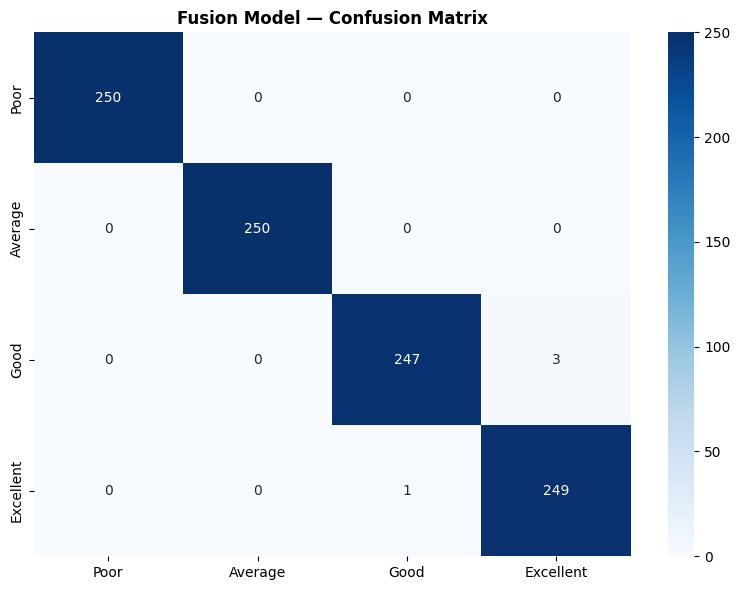

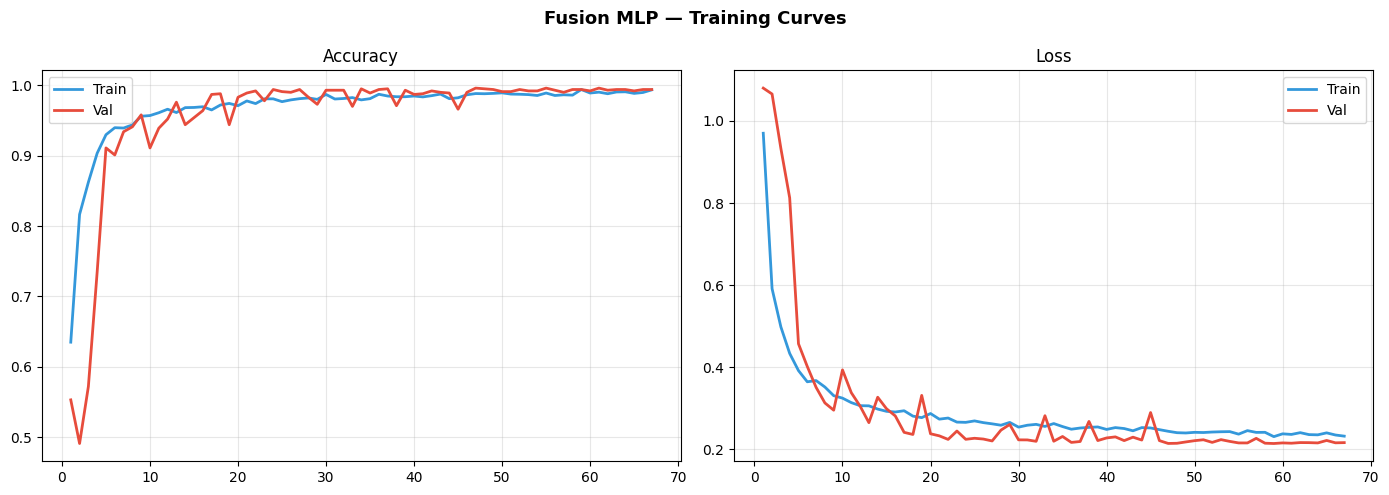

  Model      : Dual-branch MLP
  Input dim  : 30
  Classes    : 4
  Labels     : ['Poor', 'Average', 'Good', 'Excellent']
  Accuracy   : 99.60%
  Saved      : fusion_model_final.keras


In [ ]:
# ── Evaluate + Plot + Save ────────────────────────────
test_loss, test_acc = fusion_model.evaluate(
    X_te, y_te_cat, verbose=0)
print(f"✅ Test Accuracy : {test_acc*100:.2f}%")

y_pred     = fusion_model.predict(
    X_te, verbose=0)
y_pred_cls = np.argmax(y_pred, axis=1)

print(classification_report(
    y_te, y_pred_cls,
    target_names=list(PERF_LABELS.values())))

cm = confusion_matrix(y_te, y_pred_cls)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
    xticklabels=PERF_LABELS.values(),
    yticklabels=PERF_LABELS.values(),
    cmap='Blues')
plt.title('Fusion Model — Confusion Matrix',
          fontweight='bold')
plt.tight_layout()
plt.show()

# Training curves
acc   = history.history['accuracy']
val   = history.history['val_accuracy']
loss  = history.history['loss']
vloss = history.history['val_loss']
ep    = range(1, len(acc)+1)

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Fusion MLP — Training Curves',
             fontsize=13, fontweight='bold')
axes[0].plot(ep, acc,  color='#3498db',
    linewidth=2, label='Train')
axes[0].plot(ep, val,  color='#e74c3c',
    linewidth=2, label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(ep, loss,  color='#3498db',
    linewidth=2, label='Train')
axes[1].plot(ep, vloss, color='#e74c3c',
    linewidth=2, label='Val')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save
fusion_model.save(
    f'{MODEL_SAVE}/fusion_model_final.keras')

fusion_meta = {
    'input_dim'   : int(X_fusion.shape[1]),
    'num_classes' : NUM_CLASSES,
    'labels'      : PERF_LABELS,
    'accuracy'    : float(test_acc),
    'face_emotions' : FACE_EMOTIONS,
    'audio_emotions': AUDIO_EMOTIONS,
    'text_emotions' : id2emotion,
    'interview_dims': INTERVIEW_DIMS,
    'score_mapping' : {
        'Poor'     : '0-40',
        'Average'  : '40-60',
        'Good'     : '60-80',
        'Excellent': '80-100'
    }
}

with open(f'{FUSION_ARRAYS}/fusion_meta.json',
          'w') as f:
    json.dump(fusion_meta, f, indent=2)

print(f"  Model      : Dual-branch MLP")
print(f"  Input dim  : {X_fusion.shape[1]}")
print(f"  Classes    : {NUM_CLASSES}")
print(f"  Labels     : {list(PERF_LABELS.values())}")
print(f"  Accuracy   : {test_acc*100:.2f}%")
print(f"  Saved      : fusion_model_final.keras")

In [ ]:
# ── Test End-to-End Fusion ────────────────────────────
def predict_interview_performance(
        face_result,
        audio_result,
        text_result,
        speech_quality=None):
    """
    Full fusion prediction
    Returns performance label + score 0-100
    """
    # Build fusion vector
    vec = build_fusion_vector(
        face_result, audio_result,
        text_result, speech_quality)

    # Predict
    vec_input = vec.reshape(1, -1)
    probs = fusion_model.predict(
        vec_input, verbose=0)[0]
    pred  = np.argmax(probs)

    # Map to 0-100 score
    score_ranges = {
        0: (0,  40),
        1: (40, 60),
        2: (60, 80),
        3: (80, 100)
    }
    low, high = score_ranges[pred]
    score = low + probs[pred] * (high-low)

    # 4 dimension scores
    dim_scores = {
        'Confidence'  : round(
            float(probs[2]*30 +
                  probs[3]*70 +
                  probs[1]*50), 1),
        'Clarity'     : round(
            float(speech_quality.get(
                'clarity_score', 50)
                if speech_quality else 50), 1),
        'Positivity'  : round(
            float(probs[2]*80 +
                  probs[3]*100 +
                  probs[1]*40 +
                  probs[0]*20), 1),
        'Answer Quality': round(
            float(probs[2]*70 +
                  probs[3]*90 +
                  probs[1]*50 +
                  probs[0]*20), 1)
    }

    return {
        'label'      : PERF_LABELS[pred],
        'score'      : round(float(score), 1),
        'probs'      : {
            PERF_LABELS[i]: round(float(p),3)
            for i,p in enumerate(probs)},
        'dim_scores' : dim_scores,
        'face_emotion' : face_result[
            'emotion'],
        'audio_emotion': audio_result[
            'emotion'],
        'text_emotion' : text_result[
            'emotion']
    }

# Test with sample data
print("🎯 Testing end-to-end fusion...")
result = predict_interview_performance(
    face_result  = test_face,
    audio_result = test_audio,
    text_result  = test_text,
    speech_quality = {
        'clarity_score'      : 85,
        'fluency_score'      : 80,
        'filler_ratio'       : 0.02,
        'vocabulary_richness': 0.75,
        'total_words'        : 120})

print(f"\n{'='*50}")
print(f"INTERVIEW PERFORMANCE RESULT")
print(f"{'='*50}")
print(f"  Label       : {result['label']}")
print(f"  Score       : {result['score']}/100")
print(f"\n  Probabilities:")
for k,v in result['probs'].items():
    bar = '█' * int(v*20)
    print(f"    {k:10s}: {bar} {v:.3f}")
print(f"\n  Dimension Scores:")
for k,v in result['dim_scores'].items():
    print(f"    {k:15s}: {v}/100")
print(f"\n  Detected emotions:")
print(f"    Face  : {result['face_emotion']}")
print(f"    Audio : {result['audio_emotion']}")
print(f"    Text  : {result['text_emotion']}")

🎯 Testing end-to-end fusion...

INTERVIEW PERFORMANCE RESULT
  Label       : Excellent
  Score       : 99.3/100

  Probabilities:
    Poor      :  0.009
    Average   :  0.008
    Good      :  0.017
    Excellent : ███████████████████ 0.966

  Dimension Scores:
    Confidence     : 68.5/100
    Clarity        : 85.0/100
    Positivity     : 98.4/100
    Answer Quality : 88.7/100

  Detected emotions:
    Face  : happy
    Audio : happy
    Text  : positive
